<!-- # New nested CV for model optimization


Updated May 5 2026

- Adapt 3.3_kfold_clustered to include hyperparameter search  -->

In [ ]:
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm

from datetime import datetime
import gsw
import mod_argo
import matplotlib.pyplot as plt
from cmocean import cm as cmo

import mod_plotting as mod_plot
import mod_southpolarplot as sopo
from cartopy import crs as ccrs

import figs_pcm
import mod_pcm
import mod_regression as mod_reg
import mod_preprocessing as mod_prep
reload(mod_reg)

datetag = datetime.now().strftime('%Y%m%d')


<!-- # 1.0 Setup data -->

In [ ]:
reload(loader)

# ==== choose data run parameters
float_carbon_var= 'pHbias5_pK1'
pcm_params='pc8_gmm6'
n_gmm = int(pcm_params.split('_')[1][-1])
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params
print(desc + '; ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
# ===== import 

# Import clustered data 
# datetag: 20260211 without 2024 data clustered; 20260327 with 2024 data clustered
[bgcArgo_trainval, bgcArgo_test, 
        socat_trainval, socat_test, coreArgo_application] = loader.import_p2_clustered(type = 'class-gapfilled', pcm_params=pcm_params,
                                                                                       datetag = '20260327')

print(len(bgcArgo_trainval), len(bgcArgo_test), len(socat_trainval), len(socat_test), len(coreArgo_application))

floatparam_pHbias5_pK1_pc8_gmm6; 2026-05-07 09:56:24
Importing processed Dataframes with gap-filled classes; pc8_gmm6...
10781 2111 6651 417 314772


In [ ]:
for platDF in [bgcArgo_trainval, bgcArgo_test, 
        socat_trainval, socat_test, coreArgo_application]:
    mod_prep.print_bounds(platDF)

Number of observations: 10781
Dates: 		2014-04-03 22:49:59.999999 to 2023-12-30 20:03:59.999999
Number of observations: 2111
Dates: 		2024-01-01 03:59:00.000000 to 2024-12-30 15:59:00.000000
Number of observations: 6651
Dates: 		2014-01-02 11:36:53 to 2023-12-31 10:47:00
Number of observations: 417
Dates: 		2024-01-01 10:47:00 to 2024-12-31 12:04:47
Number of observations: 314772
Dates: 		2014-01-01 00:01:34.000000000 to 2023-12-30 23:59:00.000000000


In [ ]:
# === Choose exclusion
exclude_nums = [] 
n_clusters = n_gmm - len(exclude_nums) 

list = []
for df in [bgcArgo_trainval, bgcArgo_test, socat_trainval, coreArgo_application]:
    temp = mod_pcm.finalize_classes(df, exclude_nums, n_gmm=n_gmm, reassign_numbers=True)
    list.append(temp)

# Naming convention, call it "cluster" after you've taken out unwanted classes to avoid confusion with original GMM classes
bgcArgo_trainval_final = list[0][1]
bgcArgo_test_final = list[1][1]
socat_trainval_final = list[2][1]
coreArgo_application_final = list[3][1]


# ======= Adjust description and ds
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params

if len(exclude_nums) > 0:
    desc = desc + '_excludeClass' + ''.join([str(num) for num in exclude_nums])
    print('New description tag with excluded class: ')
desc

In [ ]:
from solarpy import irradiance_on_plane

bgcArgo_trainval_final = mod_prep.add_solar_radiation(bgcArgo_trainval_final, daily_max=True)
socat_trainval_final = mod_prep.add_solar_radiation(socat_trainval_final, daily_max=True)


In [ ]:
bgcArgo_trainval_final['log_mld'] = np.log(bgcArgo_trainval_final['mld'])
socat_trainval_final['log_mld'] = np.log(socat_trainval_final['mld'])

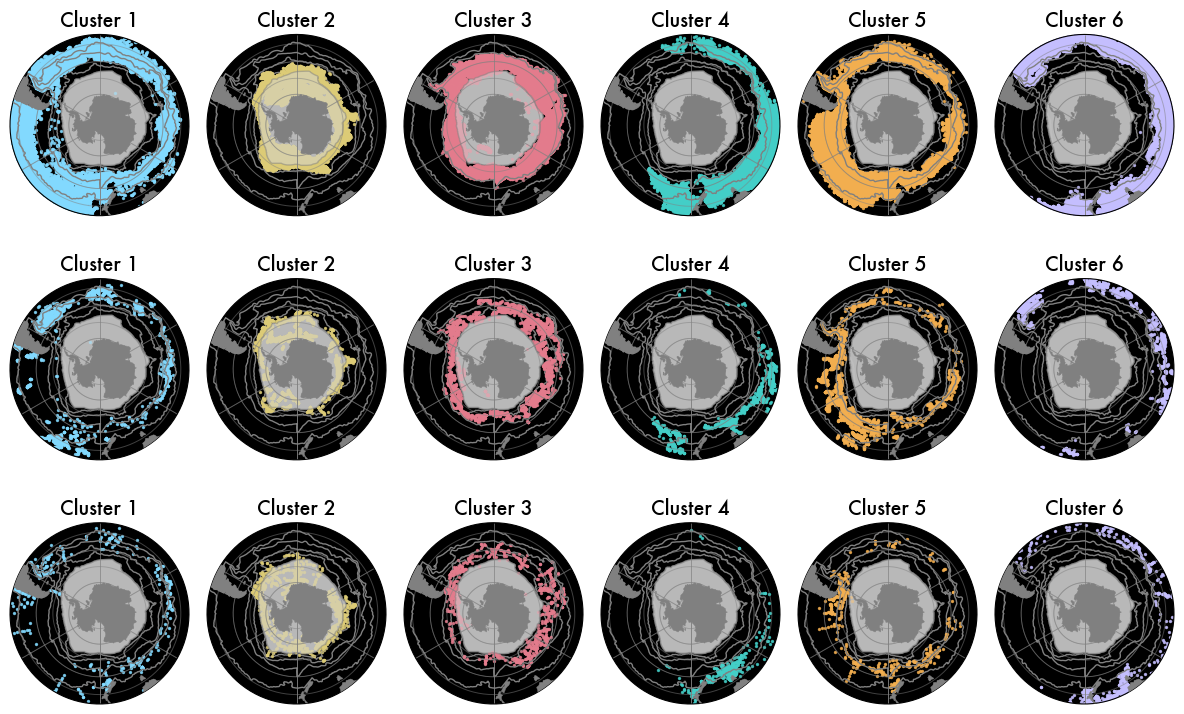

In [257]:
core_locs = {int(k):v for k,v in coreArgo_application_final.groupby('cluster')}
bgc_locs = {int(k):v for k,v in bgcArgo_trainval_final.groupby('cluster')}
socat_locs = {int(k):v for k,v in socat_trainval_final.groupby('cluster')}

# Plot all platforms

fig, axs = plt.subplots(3,6, figsize=(12,8), layout='tight', subplot_kw={'projection': ccrs.SouthPolarStereo()})

figs_pcm.sopolar_classes_paneled(core_locs, axs = axs[0,:], numpanels=[1,n_clusters]);
figs_pcm.sopolar_classes_paneled(bgc_locs, axs = axs[1,:], numpanels=[1,n_clusters]);
figs_pcm.sopolar_classes_paneled(socat_locs, axs = axs[2,:], numpanels=[1,n_clusters]);

for ax in axs.flatten():
    ax.set_facecolor('k')
    sopo.add_frontlines(ax, types=['sie']) 


In [ ]:
# Check which clusters have sea ice profiles ==> include only in clusters 2, 3 
print('ice', '\t', 'cluster', '\t', 'proportion')
for ncluster in range(1, n_gmm+1):
    cluster_data = bgcArgo_trainval_final[bgcArgo_trainval_final.cluster==ncluster]
    ice_profiles = cluster_data[cluster_data.sea_ice>0.1]
    print(len(ice_profiles), '\t', len(cluster_data),  '\t\t', len(ice_profiles)/len(cluster_data))

ice 	 cluster 	 proportion
2 	 1613 		 0.0012399256044637321
1150 	 2877 		 0.3997219325686479
73 	 2390 		 0.030543933054393305
0 	 881 		 0.0
0 	 2145 		 0.0
0 	 875 		 0.0


<!-- # Set up folds for cross-validation -->

In [268]:
# Check which clusters have sea ice profiles ==> include only in clusters 2, 3 
print('cluster', '\t', 'nobs', '\t', 'float_obs', '\t', 'socat_obs')
combined_trainval = pd.concat([bgcArgo_trainval_final, socat_trainval_final])

for ncluster in range(1, n_gmm+1):
    cluster_data = combined_trainval[combined_trainval.cluster==ncluster]
    float_data = bgcArgo_trainval_final[bgcArgo_trainval_final.cluster==ncluster]
    ship_data = socat_trainval_final[socat_trainval_final.cluster==ncluster]
    print(ncluster, '\t\t', len(cluster_data),  '\t', len(float_data), '\t\t', len(ship_data))

cluster 	 nobs 	 float_obs 	 socat_obs
1 		 2025 	 1613 		 412
2 		 4073 	 2877 		 1196
3 		 3372 	 2390 		 982
4 		 3207 	 881 		 2326
5 		 2676 	 2145 		 531
6 		 2079 	 875 		 1204


<!-- - NestedCrossValContainer object from mod_reg, one for each SO class
    - Fields are: 
        outer_trainDF, outer_valDF: dictionary keyed by fold list (['fold1', 'fold2',...])
        inner_trainDF, inner_valDF: dictionary keyed by inner fold list. uses only training data corresponding to outer fold 



- Example: Hyperparameter tuning for Cluster 1 observations, for outer fold 1 
    - Access the inner_nests object and getting the nested training DF for the second inner fold using:  
        `soclass_cvtainers['cluster1'].inner_nests['fold1'].trainDF['fold2']` -->

In [ ]:
# bgcArgo_trainval_final.columns

Index(['wmoid', 'prof_datetag', 'datetime', 'latitude', 'longitude', 'ydcos',
       'ydsin', 'year', 'month', 'day', 'CT', 'SA', 'sst', 'sss', 'mld', 'adt',
       'wind_components', 'wind_speed', 'sea_ice', 'atmos_pres_Pa',
       'atmos_pres_atm', 'vapor_pres_atm', 'pCO2_standard', 'pCO2_pHbias3',
       'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1', 'pco2_atmos',
       'pco2_ocean', 'delta_pco2', 'class_assign', 'platform', 'cluster1_prob',
       'cluster2_prob', 'cluster3_prob', 'cluster4_prob', 'cluster5_prob',
       'cluster6_prob', 'cluster', 'max_solar_rad', 'log_mld'],
      dtype='object')

In [ ]:
# MAIN SETUP CELL May 7 2026
# will need to adjust mod_reg.subset_folds() to do spatial CV 

n_outer=5 # main comparison
n_inner=4 # tuning
float_data = bgcArgo_trainval_final.copy()
socat_data = socat_trainval_final.copy()

# Add

# Initailize main dictionary to hold nestedCV containers for each class
soclass_list = ['cluster' + str(k) for k in range(1, n_clusters+1)]
soclass_cvtainers = {soclass: None for soclass in soclass_list}

# Set up a separate nestedCV object for each class
for soclass in range(1, n_clusters+1):
    classDF_float = float_data[float_data['cluster'] == soclass]
    classDF_ship = socat_data[socat_data['cluster'] == soclass]

    # Set up outer folds, for both ship and float
    outer_nest = mod_reg.NestedCrossValContainer(n_outer) # Store in soclass_cvtainers[soclass]
    [outer_train_float, outer_val_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=n_outer)
    [outer_train_ship, outer_val_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=n_outer)
    for outfold in range(1, n_outer+1):
        outtag = 'fold' + str(outfold)
        outer_nest.trainDF[outtag] = pd.concat([outer_train_float[outtag], outer_train_ship[outtag]], axis=0)
        outer_nest.valDF[outtag] = pd.concat([outer_val_float[outtag], outer_val_ship[outtag]], axis=0)

        # Set up inner folds, one object for each outer fold (outtag) -- now use outer training data only for split
        inner_nest = mod_reg.NestedCrossValContainer(n_inner) # Store in outer_nest.inner_nests
        [inner_train_float, inner_val_float] = mod_reg.subset_folds(outer_train_float[outtag], indexer='wmoid', nfolds=n_outer)
        [inner_train_ship, inner_val_ship] = mod_reg.subset_folds(outer_train_ship[outtag], indexer='cruiseid', nfolds=n_outer)
        for infold in range(1, n_inner+1):
            intag = 'fold' + str(infold)
            inner_nest.trainDF[intag] = pd.concat([inner_train_float[intag], inner_train_ship[intag]], axis=0)
            inner_nest.valDF[intag] = pd.concat([inner_val_float[intag], inner_val_ship[intag]], axis=0)

        # Save inner fold objects (one for each outer fold)
        outer_nest.inner_nests[outtag] = inner_nest

    # Save outer fold objects (one for each class) 
    soclass_cvtainers['cluster' + str(soclass)] = outer_nest


In [ ]:
# Hyperparameter tuning for Cluster 1 observations, for outer fold 1 
# Access the inner_nests object and getting the nested training DF for the second inner fold 
soclass_cvtainers['cluster1'].inner_nests['fold1'].trainDF['fold2'].columns

Index(['wmoid', 'prof_datetag', 'datetime', 'latitude', 'longitude', 'ydcos',
       'ydsin', 'year', 'month', 'day', 'CT', 'SA', 'sst', 'sss', 'mld', 'adt',
       'wind_components', 'wind_speed', 'sea_ice', 'atmos_pres_Pa',
       'atmos_pres_atm', 'vapor_pres_atm', 'pCO2_standard', 'pCO2_pHbias3',
       'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1', 'pco2_atmos',
       'pco2_ocean', 'delta_pco2', 'class_assign', 'platform', 'cluster1_prob',
       'cluster2_prob', 'cluster3_prob', 'cluster4_prob', 'cluster5_prob',
       'cluster6_prob', 'cluster', 'max_solar_rad', 'log_mld', 'cruiseid',
       'linear_time', 'nearest_profid', 'prof_datetime', 'prof_lat',
       'prof_lon', 'yd_sep', 'km_sep', 'fco2rec'],
      dtype='object')

In [ ]:
trying  new nestedCV
Different architecture, now store class data in a dictionary
Each dictionary item holds a NestedCV container with outer/inner folds for parameter/hyperparameter tuning

n_outer=5 # main comparison
n_inner=4 # tuning
float_data = bgcArgo_trainval_final.copy()
socat_data = socat_trainval_final.copy()

# Initailize main dictionary to hold nestedCV containers for each class
outer_cvtainers = {soclass: mod_reg.NestedCrossValContainer(n_outer, n_inner) for soclass in range(1, n_clusters+1)}

# Set up a separate nestedCV object for each class
for soclass in range(1, n_clusters+1):
    classDF_float = float_data[float_data['cluster'] == soclass]
    classDF_ship = socat_data[socat_data['cluster'] == soclass]

    # Set up outer folds, for both ship and float
    [outer_train_float, outer_val_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=n_outer)
    [outer_train_ship, outer_val_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=n_outer)
    for outfold in range(1, n_outer+1):
        outtag = 'fold' + str(outfold)
        outer_cvtainers[soclass].outer_trainDF[outtag] = pd.concat([outer_train_float[outtag], outer_train_ship[outtag]], axis=0)
        outer_cvtainers[soclass].outer_valDF[outtag] = pd.concat([outer_val_float[outtag], outer_val_ship[outtag]], axis=0)
        
        # Set up inner folds -- now use training data only from the outer fold
        [inner_train_float, inner_val_float] = mod_reg.subset_folds(outer_train_float[outtag], indexer='wmoid', nfolds=n_outer)
        [inner_train_ship, inner_val_ship] = mod_reg.subset_folds(outer_train_ship[outtag], indexer='cruiseid', nfolds=n_outer)
        for infold in range(1, n_inner+1):
            intag = 'fold' + str(infold)
            outer_cvtainers[soclass].inner_trainDF[intag] = pd.concat([inner_train_float[intag], 
                                                                        inner_train_ship[intag]], axis=0)
            outer_cvtainers[soclass].inner_valDF[intag] = pd.concat([inner_val_float[intag],
                                                                        inner_val_ship[intag]], axis=0)
            

In [ ]:
# MAIN RUN UPDATED APR 2026 - from 3.3 
# [bgcArgo_trainval, bgcArgo_test, socat_trainval, coreArgo_application]

nfolds = 5
trainvalDF_all = pd.concat([bgcArgo_trainval_final, socat_trainval_final], axis=0)

# Initialize object 
cvtainer = mod_reg.CrossValContainer(fold_list = ['fold' + str(k) for k in range(1, nfolds+1)], n_clusters = n_clusters)


for soclass in range(1, n_clusters+1):
    # print('==> Processing class ' + str(soclass))
    classDF = trainvalDF_all[trainvalDF_all['cluster'] == soclass]
    [classDF_float, classDF_ship] = mod_reg.separate_platforms(classDF)

    # trainfolds_float is a dictionary, keys are 'fold1' holding one class's training data
    [trainfolds_float, valfolds_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=nfolds)
    [trainfolds_ship, valfolds_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=nfolds)

    for nfold in range(1, nfolds+1):
        # split up the data for this southern ocean class, fill in for each fold
        foldtag = 'fold' + str(nfold)
        foldtrain_soclass = pd.concat([trainfolds_float[foldtag], trainfolds_ship[foldtag]], axis=0)
        foldval_soclass =  pd.concat([valfolds_float[foldtag], valfolds_ship[foldtag]], axis=0)


        cvtainer.trainClasses[foldtag][soclass] =  foldtrain_soclass.copy()
        cvtainer.valClasses[foldtag][soclass] =  foldval_soclass.copy()

# After separating class data into respective folds, check train/val counts by class
for nfold in range(1, nfolds+1):
    foldtag = 'fold' + str(nfold)
    
    cvtainer.countobs[foldtag] = mod_reg.get_trainval_counts(cvtainer.trainClasses[foldtag], cvtainer.valClasses[foldtag], n_gmm=n_clusters)
    cvtainer.trainDF_all[foldtag] = pd.concat(cvtainer.trainClasses[foldtag].values(), axis=0)
    cvtainer.valDF_all[foldtag] = pd.concat(cvtainer.valClasses[foldtag].values(), axis=0)

# Also add single platform dictionaries to the CrossValContainer object
for fold in cvtainer.fold_list:

    vdat_combined = cvtainer.valDF_all[fold] 


    [vdat_float, vdat_ship] = mod_reg.separate_platforms(vdat_combined)
    cvtainer.valClasses_float[fold] = {int(ncluster):df for ncluster, df in vdat_float.groupby('cluster')}
    cvtainer.valClasses_ship[fold] = {int(ncluster):df for ncluster, df in vdat_ship.groupby('cluster')}

    tdat_combined = cvtainer.trainDF_all[fold] 
    [tdat_float, tdat_ship] = mod_reg.separate_platforms(tdat_combined)
    cvtainer.trainClasses_float[fold] = {int(ncluster):df for ncluster, df in tdat_float.groupby('cluster')}
    cvtainer.trainClasses_ship[fold] = {int(ncluster):df for ncluster, df in tdat_ship.groupby('cluster')}



<!-- # Main training method -->


In [ ]:
# =========  Updated May 2026 run parameters ========= 
# Set run parameters and feature lists
reload(mod_reg)
print(desc)

use_data_split = soclass_cvtainers
# Automated version, see 3.3_kfold_clustered (use make_run_tags() from mod_reg)
# Manual set 
feat_options = {
                'featA' : ['CT', 'SA', 'log_mld', 'adt', 'sea_ice', 'wind_speed', 'atmos_pres_atm', 'max_solar_rad']
                }

# Choose trained on ship, float, or combined
# Always validate on same set of samples
# consistent_valDF = pd.concat(cvtainer.valDF_all.values(), axis=0) # full length of training

# Regression target variables
target_options = ['delta_pco2'] #, 'pco2']
data_options = ['float', 'ship', 'combined']

run_tags = []
for key1 in feat_options.keys():
    for key2 in data_options:
        for target in target_options:
            run_tags.append(key1 + '-' + key2 + '-' + target)

# ========= Set up hyperparameter search ========= 
tuning_grid = {
    'max_features': [1/3, 1/2, None],
    'min_samples_split': [2, 5, 10]
}
ntrees = 1000
max_feats = 1/3
min_samples_split = 5

floatparam_pHbias5_pK1_pc8_gmm6


In [ ]:
# ncv = {run_tag:{nfold:None for nfold in cvtainer.fold_list} for run_tag in run_tags}
# nested_scores = {run_tag:{fold:None for fold in soclass_cvtainers['cluster1'].fold_list} for run_tag in run_tags}

In [ ]:
# == MAIN TRAINING FOR CROSS-VALIDATION (RFR), will repeat for each cluster 
# Different structure than 3.3! 
# Updated Apr 28 2026



            # Restrict platform 
            # if platform_key == 'float':
            #     fold_trainDF = fold_trainDF[~fold_trainDF.prof_datetag.isna()]
            #     fold_valDF = fold_valDF[~fold_valDF.prof_datetag.isna()]
            # elif platform_key == 'ship':
            #     fold_trainDF = fold_trainDF[~fold_trainDF.cruiseid.isna()]
            #     fold_valDF = fold_valDF[~fold_valDF.cruiseid.isna()]

nclusters = n_gmm - len(exclude_nums)
k_list = range(1,nclusters+1) # Number of clusters
sea_ice_clusters = [2,3]

print('======= Main algorithm training (' + desc + ') ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

# storedCV_siz = {}

for run_tag in tqdm(run_tags[:]):
    print('===> Training runtag (' + run_tag + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

    feat_key = run_tag.split('-')[0]
    feat_list = feat_options[feat_key]
    platform_key = run_tag.split('-')[1]
    var_predict = run_tag.split('-')[2]

    print('Features: ' + ', '.join(feat_list))

    #== Iterate over clusters here, indent training
    # Each runtag will be associated with a ClusteredModelVersion object
    RFR_clustered = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun
    
    for k in [2]: #k_list: # For each class, train a separate regression 
        ktag = 'cluster' + str(k)

        # Remove sea ice as feature where not needed
        if k not in sea_ice_clusters: class_feat_list = [x for x in feat_list if x != 'sea_ice']
        else: class_feat_list = feat_list.copy()

        # === Outer CV for overall model version validation error 
        # (combine errors across folds and populate fields in RFR_clustered, which will be stored in storedRuns)
        cluster_data = soclass_cvtainers[ktag] # nestedCV object
        outer_fold_errors = [] # list of MAEs
        outer_scores = mod_reg.NestedModelVersion(fold_list = cluster_data.fold_list)
        
        
        for outfold in cluster_data.fold_list:    # separate for each fold, same run tag
            print('\tTraining outer ' + outfold + ' for algorithm selection...')
            fold_trainDF = cluster_data.trainDF[outfold]
            fold_valDF = cluster_data.valDF[outfold]

            # ==== Inner CV for hyperparameter tuning 
            tuning_data = cluster_data.inner_nests[outfold] #nestedCV object (inside another nestedCV object)
            # to do,  iterate over try_params
            try_params = [1000, 1/3, 5]
            inner_fold_errors=[]
            inner_scores  = mod_reg.NestedModelVersion(fold_list = tuning_data.trainDF.keys())

            for infold in tuning_data.trainDF.keys(): 
                print('\t\tTraining inner ' + infold + ' for hyperparameter tuning...')
                infold_trainDF = tuning_data.trainDF[infold]
                infold_valDF = tuning_data.valDF[infold]
                
                # Grid search for hyperparameters 

                Mdl = mod_reg.fit_single_RFR(feat_list, 
                                        infold_trainDF, 
                                        var_predict = var_predict, 
                                        loss_criterion = 'squared_error',
                                        ntrees = try_params[0], 
                                        max_feats = try_params[1],
                                        min_samples_split=try_params[2])
                
                infold_validation = mod_reg.apply_single_RFR(Mdl, feat_list, fold_valDF, sample_tag='tuning', target_known=True)
                inner_fold_errors = inner_fold_errors + [infold_validation]
            
            # Compare the results of different hyperparameter combos
            

            # Use tuned hyperparameters to train model on full training fold, then estimate overall error on outer fold valDF
            # tuned_ntrees = 1000
            # tuned_max_feats = 1/3
            # tuned_min_samples_split = 5
            # RFR_clustered.models[k] = mod_reg.fit_single_RFR(feat_list, 
            #                             fold_trainDF, 
            #                             var_predict = var_predict, 
            #                             loss_criterion = 'squared_error',
            #                             ntrees = tuned_ntrees, max_feats = tuned_max_feats,
            #                             min_samples_split=tuned_min_samples_split)
            
        # === OVERALL RUNTAG ERROR
        # RFR_clustered.weighted_training = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_trainDF, sample_tag='train')
        # RFR_clustered.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_valDF, sample_tag='val')
        # storedCV_siz[run_tag][nfold] = RFR_clustered

            # === VALIDATION ERRORS (and training errors for calibration)
    

## Main training

<!-- # Best version May 2026 =  alt implementation using grid search -->


In [ ]:
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut

In [ ]:
# == UPDATED ALTERNATIVE TRAINING FOR CROSS-VALIDATION TRYING USING GRIDSEARCH CV 
# Different structure than 3.3! 
# Updated 
            # Restrict platform 
            # if platform_key == 'float':
            #     fold_trainDF = fold_trainDF[~fold_trainDF.prof_datetag.isna()]
            #     fold_valDF = fold_valDF[~fold_valDF.prof_datetag.isna()]
            # elif platform_key == 'ship':
            #     fold_trainDF = fold_trainDF[~fold_trainDF.cruiseid.isna()]
            #     fold_valDF = fold_valDF[~fold_valDF.cruiseid.isna()]

nclusters = n_gmm - len(exclude_nums)
k_list = range(1,nclusters+1) # Number of clusters
sea_ice_clusters = [2,3]

use_regressor = RandomForestRegressor(random_state=42)

# print('======= Main algorithm training (' + desc + ') ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S') )
# storedCV = {run_tag:{nfold:None for nfold in range(1, n_outer+1)} for run_tag in run_tags}
# for run_tag in tqdm(run_tags[:]):
#     print('===> Training runtag (' + run_tag + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

RunTagResults = {nfold:None for nfold in range(1, n_outer+1)}

run_tag = run_tags[0]

feat_key = run_tag.split('-')[0]
feat_list = feat_options[feat_key]
platform_key = run_tag.split('-')[1]
var_predict = run_tag.split('-')[2]

print('Features: ' + ', '.join(feat_list))

#== Iterate over clusters here, indent training
# Each runtag will be associated with a ClusteredModelVersion object
RFR_clustered = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun

for k in [2]: #k_list: # For each class, train a separate regression 
    ktag = 'cluster' + str(k)

    # Remove sea ice as feature where not needed
    if k not in sea_ice_clusters: class_feat_list = [x for x in feat_list if x != 'sea_ice']
    else: class_feat_list = feat_list.copy()

    # === Outer CV for overall model version validation error 
    # (combine errors across folds and populate fields in RFR_clustered, which will be stored in storedRuns)
    cluster_data = soclass_cvtainers[ktag] # nestedCV object
    class_models = []

    fold_scores = mod_reg.NestedModelVersion(fold_list = cluster_data.fold_list, feat_list = class_feat_list) # analogous to ClusteredModelVersion
    for outfold in cluster_data.fold_list:    # separate for each fold, same run tag
        print('\tTraining outer ' + outfold + ' for algorithm selection...')

        # ==== Inner CV for hyperparameter tuning 
        logo_cv = LeaveOneGroupOut()
        logo_X = pd.DataFrame()
        tuning_data = cluster_data.inner_nests[outfold] # fold_trainDF.copy()
        
        # replace with spatial grouping k means
        for fnum, ftag in enumerate(tuning_data.valDF.keys()):
            infold = tuning_data.valDF[ftag].dropna(subset=(feat_list + [var_predict]))
            infold['inner_fold'] = ftag
            logo_X = pd.concat([logo_X, infold], axis=0)

        # Iterating over inner folds with GridSearchCV to find best hyperparameters
        clf = GridSearchCV(estimator=use_regressor, param_grid=tuning_grid, cv=logo_cv)
        inner_clf = clf.fit(X=logo_X[feat_list], y=logo_X[var_predict], groups=logo_X['inner_fold'])
        # ==== 

        # Use tuned hyperparameters for best estimator for this particular outer fold 
        best_inner_model = inner_clf.best_estimator_ # already refit on all tuning_data
        # outer_results = mod_reg.apply_single_RFR(best_inner_model, feat_list, 
        #                                             cluster_data.valDF[outfold], 
        #                                             sample_tag='val', 
        #                                             target_known=True)
        # fold_scores.model = best_inner_model
        # fold_scores.estimates[outfold] = outer_results
        class_models.append(best_inner_model) # List of four estimators, one for each outer fold 

    # To-do:  Pick which of the best estimators you will store for this SO class 
    RFR_clustered.models[k] = class_models[0]

    # RFR_clustered.models[k] = best_inner_model

# == 
RFR_clustered.weighted_training = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_trainDF, sample_tag='train')
RFR_clustered.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_valDF, sample_tag='val')

storedCV[run_tag][nfold] = RFR_clustered


<!-- # CURRENT BEST TRY -->

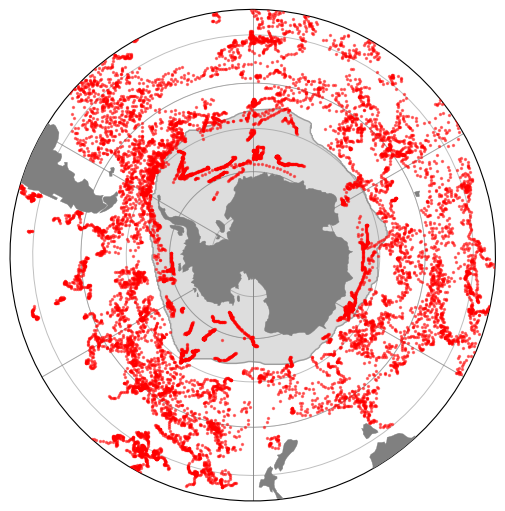

In [256]:
ax = sopo.map_platformDF(bgcArgo_trainval_final, ax=None, figsize=(5,5), dotsize=2, markerscale=8, dotalpha=0.5, dotcolor='r')

In [ ]:
def run_nested_CV(run_tag, soclass_cvtainers,
                  nclusters, k_list, sea_ice_clusters, 
                  use_regressor, tuning_grid):
    print('===> Training runtag (' + run_tag + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

    feat_key = run_tag.split('-')[0]
    feat_list = feat_options[feat_key]
    platform_key = run_tag.split('-')[1]
    var_predict = run_tag.split('-')[2]

    print('Features: ' + ', '.join(feat_list))
    RunTagResults = {nfold:None for nfold in range(1, n_outer+1)}
    #== Iterate over FOLDS here, indent training
    # === Outer CV for overall model version validation error 
    # (each fold will populate fields in fold_CMV, which will be combined in storedRuns)

    for outfold in range(1, n_outer+1): #n_outer+1):
        print('\tTraining outer fold' + str(outfold) + ' for algorithm selection')
        # For each fold, need to train separate model for each cluster
        # Each fold will be associated with a ClusteredModelVersion object
        fold_CMV = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun
        fold_valDF = pd.DataFrame()


        for k in k_list: # For each class, train a separate regression 
            ktag = 'cluster' + str(k)
            cluster_data = soclass_cvtainers[ktag] # nestedCV object
            fold_valDF = pd.concat([fold_valDF, cluster_data.valDF['fold'+str(outfold)]], axis=0) # this fold's validation data

            # Remove sea ice as feature where not needed
            if k not in sea_ice_clusters: 
                class_feat_list = [x for x in feat_list if x != 'sea_ice']
                # print('No sea ice in class ' + str(k) + ', removing from features for this class')
            else: class_feat_list = feat_list.copy()

            # ==== Inner CV for hyperparameter tuning 
            print('\t\tTraining ' + ktag + ' inner folds for hyperparameter tuning...')
            logo_cv = LeaveOneGroupOut()
            logo_X = pd.DataFrame()
            tuning_data = cluster_data.inner_nests['fold'+str(outfold)] # fold_trainDF.copy()
            
            # make input array for GridSearchCV with groups for LeaveOneGroupOut splitting
            for fnum, ftag in enumerate(tuning_data.valDF.keys()):
                infold = tuning_data.valDF[ftag].dropna(subset=(class_feat_list + [var_predict])).copy()
                infold.loc[:,'inner_fold'] = np.tile(ftag, len(infold)) # assign group number for cv splitting
                logo_X = pd.concat([logo_X, infold], axis=0)

            # print('break2') 
            # print(logo_X[class_feat_list])
            # Iterating over inner folds with GridSearchCV to find best hyperparameters
            clf = GridSearchCV(estimator=use_regressor, param_grid=tuning_grid, cv=logo_cv)
            inner_clf = clf.fit(X=logo_X[class_feat_list], y=logo_X[var_predict], groups=logo_X['inner_fold'])
            # ==== 

            # Use tuned hyperparameters for best estimator for this particular outer fold, store for each class
            fold_CMV.models[k] = inner_clf.best_estimator_ # already refit on all tuning_data
    # == 

        fold_valDF = fold_valDF.dropna(subset=(feat_list + [var_predict])).copy()
        fold_CMV.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, fold_CMV, fold_valDF, sample_tag='val', sea_ice_clusters=[2,3])

        # Calibrate each fold model
        cal_coeffs = mod_reg.get_clustered_calibration_coeffs(fold_CMV.weighted_validation)
        fold_CMV.weighted_validation = mod_reg.apply_clustered_calibration(cal_coeffs, fold_CMV.weighted_validation, n_clusters)

        RunTagResults[outfold] = fold_CMV
    
    #  ===  Collapse errors across folds so you can treat as storedRuns for comparison and visualization functions
    runtag_collapsed = mod_reg.ClusteredModelVersion(ind_list = k_list)

    singleRun_errors_across_folds = pd.DataFrame()
    for nfold in RunTagResults.keys():
        tempDF = RunTagResults[nfold].weighted_validation
        tempDF['fold'] = np.tile(nfold, len(tempDF))
        singleRun_errors_across_folds = pd.concat([singleRun_errors_across_folds, tempDF], axis=0)

    runtag_collapsed.weighted_validation = singleRun_errors_across_folds    
    
    return runtag_collapsed



In [ ]:
# Method version May 14 2026 


In [ ]:
# == May 10 2026 TRYING TRAINING FOR CROSS-VALIDATION -- NEST BY CLUSTER AGAIN. BACK TO ORIGINAL ARCHITECTURE 

run_tag = run_tags[0]

# COMMENT OUT IF YOU DONT WANT TO REPLACE 
RunTagResults = {nfold:None for nfold in range(1, n_outer+1)}

nclusters = n_gmm - len(exclude_nums)
k_list = range(1,nclusters+1) # Number of clusters
sea_ice_clusters = [2,3]

use_regressor = RandomForestRegressor(random_state=42)

# print('======= Main algorithm training (' + desc + ') ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S') )
# storedCV = {run_tag:{nfold:None for nfold in range(1, n_outer+1)} for run_tag in run_tags}
# for run_tag in tqdm(run_tags[:]):
#     print('===> Training runtag (' + run_tag + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )


feat_key = run_tag.split('-')[0]
feat_list = feat_options[feat_key]
platform_key = run_tag.split('-')[1]
var_predict = run_tag.split('-')[2]

print('Features: ' + ', '.join(feat_list))

#== Iterate over FOLDS here, indent training
# === Outer CV for overall model version validation error 
# (each fold will populate fields in fold_CMV, which will be combined in storedRuns)

for outfold in range(1, n_outer+1): #n_outer+1):
    print('\tTraining outer fold' + str(outfold) + ' for algorithm selection')
    # For each fold, need to train separate model for each cluster
    # Each fold will be associated with a ClusteredModelVersion object
    fold_CMV = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun
    fold_valDF = pd.DataFrame()


    for k in k_list: # For each class, train a separate regression 
        ktag = 'cluster' + str(k)
        cluster_data = soclass_cvtainers[ktag] # nestedCV object
        fold_valDF = pd.concat([fold_valDF, cluster_data.valDF['fold'+str(outfold)]], axis=0) # this fold's validation data

        # Remove sea ice as feature where not needed
        if k not in sea_ice_clusters: 
            class_feat_list = [x for x in feat_list if x != 'sea_ice']
            # print('No sea ice in class ' + str(k) + ', removing from features for this class')
        else: class_feat_list = feat_list.copy()

        # ==== Inner CV for hyperparameter tuning 
        print('\t\tTraining ' + ktag + ' inner folds for hyperparameter tuning...')
        logo_cv = LeaveOneGroupOut()
        logo_X = pd.DataFrame()
        tuning_data = cluster_data.inner_nests['fold'+str(outfold)] # fold_trainDF.copy()
        
        # make input array for GridSearchCV with groups for LeaveOneGroupOut splitting
        for fnum, ftag in enumerate(tuning_data.valDF.keys()):
            infold = tuning_data.valDF[ftag].dropna(subset=(class_feat_list + [var_predict])).copy()
            infold.loc[:,'inner_fold'] = np.tile(ftag, len(infold)) # assign group number for cv splitting
            logo_X = pd.concat([logo_X, infold], axis=0)

        # print('break2') 
        # print(logo_X[class_feat_list])
        # Iterating over inner folds with GridSearchCV to find best hyperparameters
        clf = GridSearchCV(estimator=use_regressor, param_grid=tuning_grid, cv=logo_cv)
        inner_clf = clf.fit(X=logo_X[class_feat_list], y=logo_X[var_predict], groups=logo_X['inner_fold'])
        # ==== 

        # Use tuned hyperparameters for best estimator for this particular outer fold, store for each class
        fold_CMV.models[k] = inner_clf.best_estimator_ # already refit on all tuning_data
# == 

    fold_valDF = fold_valDF.dropna(subset=(feat_list + [var_predict])).copy()
    fold_CMV.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, fold_CMV, fold_valDF, sample_tag='val', sea_ice_clusters=[2,3])

    # Calibrate each fold model
    cal_coeffs = mod_reg.get_clustered_calibration_coeffs(fold_CMV.weighted_validation)
    fold_CMV.weighted_validation = mod_reg.apply_clustered_calibration(cal_coeffs, fold_CMV.weighted_validation, n_clusters)

    RunTagResults[outfold] = fold_CMV



Features: CT, SA, log_mld, adt, sea_ice, wind_speed, atmos_pres_atm, max_solar_rad
	Training outer fold1 for algorithm selection
		Training cluster1 inner folds for hyperparameter tuning...
		Training cluster2 inner folds for hyperparameter tuning...
		Training cluster3 inner folds for hyperparameter tuning...
		Training cluster4 inner folds for hyperparameter tuning...
		Training cluster5 inner folds for hyperparameter tuning...
		Training cluster6 inner folds for hyperparameter tuning...


/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/sklearn/base.py:493: UserWarn

In [ ]:
# # If running calibration after training
# for key, cvmodel in RunTagResults.items():    # Calibrate each fold model
#     cal_coeffs = mod_reg.get_clustered_calibration_coeffs(cvmodel.weighted_validation)
#     RunTagResults[key].weighted_validation = mod_reg.apply_clustered_calibration(cal_coeffs, cvmodel.weighted_validation, n_clusters)


In [276]:
# RunTagResults

#  ==========  Collapse errors across folds so you can treat as storedRuns for comparison and visualization functions

tempRun = mod_reg.ClusteredModelVersion(ind_list = k_list)
singleRun_errors_across_folds = pd.DataFrame()

for nfold in RunTagResults.keys():
    tempDF = RunTagResults[nfold].weighted_validation
    tempDF['fold'] = np.tile(nfold, len(tempDF))
    singleRun_errors_across_folds = pd.concat([singleRun_errors_across_folds, tempDF], axis=0)

# storedCV_collapsed_siz[run_tag] = singleRun_errors_across_folds
tempRun.weighted_validation = singleRun_errors_across_folds
# storedCV_collapsed_siz[run_tag] = tempRun

In [290]:
mod_reg.singleRun_class_summary(tempRun, error_param = 'val_error')

,median_AE,mean_AE,bias,rmse
1,15.016922,21.204641,1.263096,30.267846
2,18.515226,23.588314,0.096657,31.303791
3,11.376507,15.200064,0.630006,21.198926
4,6.487601,9.675135,0.55431,14.232885
5,14.411232,16.309279,-0.450306,20.457
6,9.838728,12.293838,0.967101,16.132664
overall,12.012008,16.650575,0.437805,23.533988


In [291]:
mod_reg.singleRun_class_summary(tempRun, error_param = 'calibrated_error')

,median_AE,mean_AE,bias,rmse
1,14.857187,20.723787,0.209455,29.428132
2,17.994993,22.994065,0.015951,30.450754
3,11.181293,14.89904,-0.049836,20.640554
4,6.554967,9.385207,0.03176,13.550574
5,13.378365,15.189349,-0.191274,18.975924
6,9.34258,11.715625,-0.043812,15.473012
overall,11.733379,16.103265,-0.010768,22.722028


In [292]:
# mod_reg.singleRun_class_summary(tempRun)
mod_reg.singleRun_platform_summary(tempRun)

,median_AE,mean_AE,bias,rmse
overall,12.012008,16.650575,0.437805,23.533988
float_component,15.477158,19.218922,-0.619400,25.759883
ship_component,8.093098,12.456465,2.164219,19.356421


In [294]:
print('Linearly calibrated by class')
(mod_reg.storedRuns_comparison(singleRun_errors_across_folds, run_tags[:], error_param='calibrated_error',
                               show_platforms='combined')
                                .sort_values('RMSE')
)

Linearly calibrated by class


KeyError: 'featA-float-delta_pco2'

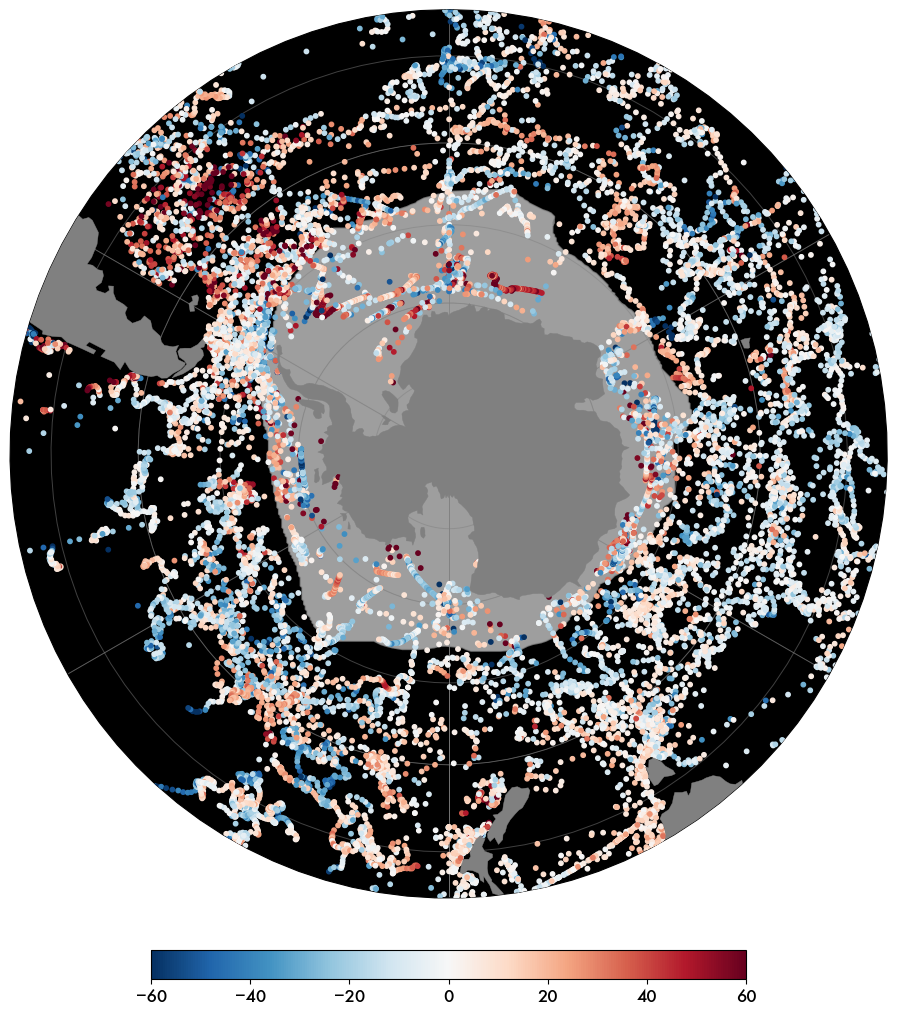

In [286]:
plot_data = tempRun.weighted_validation
# ax = sopo.map_platformDF(plot_data, ax=None, figsize=(9,9), dotsize=16, markerscale=3, dotalpha=1, 
#                          dotcolor= plot_data.calibrated_error, # figs_dd.plat_colors['bgc'], 
#                          label='')

plt.rcParams.update(mod_plot.my_params(12))
fig = plt.figure(figsize=(10,10), layout='constrained')
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='k')

sca = ax.scatter(plot_data.longitude, plot_data.latitude, alpha=1, s=10, 
        transform=ccrs.PlateCarree(), zorder=10,
        label=(''), c=plot_data.calibrated_error, cmap='RdBu_r', vmin=-60, vmax=60)

# plt.colorbar(sca, shrink=0.5, label = res_delta_tag)
plt.colorbar(sca, ax=ax, orientation='horizontal', pad=0.05, aspect=20, shrink=0.6) #, label=res_delta_tag)


# ax.add_patch(fronts_patch('sie')) #sie

ax.set_facecolor('k')
sopo.add_frontlines(ax, types=['sie']) 


In [288]:
import figs_datadistributions as figs_dd

Text(0.5, 0, 'Residual Δ-pCO$_{2}$ (µatm)')

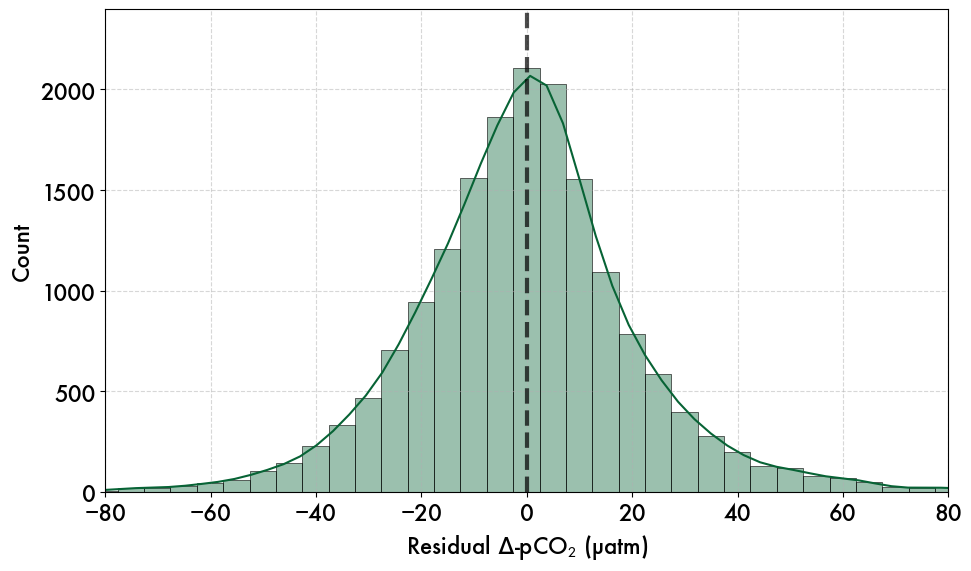

In [289]:
fig = plt.figure(figsize=(10,6), layout='tight')
ax = plt.gca()

plt.rcParams.update(mod_plot.my_params(16))
plot_data = tempRun.weighted_validation
figs_dd.overlay_histograms_singleVar({'test' : plot_data},
                                     'calibrated_error', 
                                     ax=ax, binwidth=5, 
                                      showLegend=False)

ax.set_xlim([-80,80])
ax.vlines(x=0, ymin=0, ymax=2400, colors='k', linestyles='dashed', linewidth=3, alpha=0.7, zorder=10)

ax.set_ylim([0, 2400])
res_delta_tag = 'Residual Δ-pCO$_{2}$ (µatm)'
ax.set_xlabel(res_delta_tag)

# ARCHIVE DEVELOPMENT

In [ ]:
# # developing leave one out inner cv
# use_regressor = RandomForestRegressor(random_state=42)

# outer_groups = []
# logo_X = pd.DataFrame()

# soclass_data = soclass_cvtainers['cluster1']

# for fnum, ftag in enumerate(soclass_data.fold_list):
#     temp = soclass_data.valDF[ftag].dropna(subset=(feat_list + [var_predict]))
#     temp['fold'] = ftag
#     logo_X = pd.concat([logo_X, temp], axis=0)
#     outer_groups = outer_groups + [fnum]*len(temp)

# # logo_X = logo_X.dropna(subset=(feat_list + [var_predict]))
# # X = pd.concat([bgcArgo_trainval_final.copy(), socat_trainval_final.copy()])[feat_options['featA']]
# # y = pd.concat([bgcArgo_trainval_final.copy(), socat_trainval_final.copy()])['delta_pco2']

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/92574000.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['fold'] = ftag
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/92574000.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['fold'] = ftag
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/92574000.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

In [ ]:
# tuning_grid = {
#     'max_features': [1/3, 1/2],
#     'min_samples_split': [2, 5, 10]
# }

In [129]:
# cluster_data.inner_nests[outfold]

In [ ]:
# # === Inner grid search for hyperparameters 
# logo_cv = LeaveOneGroupOut()
# logo_X = pd.DataFrame()
# tuning_data = cluster_data.trainDF[outfold] # fold_trainDF.copy()
# # replace with spatial grouping k means

# for fnum, ftag in enumerate(cluster_data.inner_nests[outfold].valDF.keys()):
#     temp = cluster_data.inner_nests[outfold].valDF[ftag].dropna(subset=(feat_list + [var_predict]))
#     temp['inner_fold'] = ftag
#     logo_X = pd.concat([logo_X, temp], axis=0)
#     # inner_groups = inner_groups + [fnum]*len(temp)


# clf = GridSearchCV(estimator=use_regressor, param_grid=tuning_grid, cv=logo_cv)
# clf.fit(X=logo_X[feat_list], y=logo_X[var_predict], groups=logo_X['inner_fold'])

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/2191311335.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['inner_fold'] = ftag
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/2191311335.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['inner_fold'] = ftag
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_45946/2191311335.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

GridSearchCV(cv=LeaveOneGroupOut(),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_features': [0.3333333333333333, 0.5],
                         'min_samples_split': [2, 5, 10]})

In [116]:
# # Nested CV with parameter optimization


# rfr = RandomForestRegressor(random_state=42)
# # logo = LeaveOneGroupOut()

# # inner_cv = LeaveOneGroupOut(groups=inner_groups)
# outer_cv = LeaveOneGroupOut()
# clf = GridSearchCV(estimator=rfr, param_grid=tuning_grid, cv=outer_cv)
# clf.fit(X=logo_X[feat_list], y=logo_X[var_predict], groups=outer_groups)


# # nested_score = cross_val_score(clf, X=logo_X[feat_list], y=logo_X[var_predict], cv=outer_cv, groups=outer_groups)
# # nested_scores[i] = nested_score.mean()


GridSearchCV(cv=LeaveOneGroupOut(),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_features': [0.3333333333333333, 0.5],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
# clf.best_estimator_ # on whole dataset

RandomForestRegressor(max_features=0.3333333333333333, min_samples_split=10,
                      random_state=42)

In [ ]:
# 